In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

### Sample

Mean Squared Error: 19.43


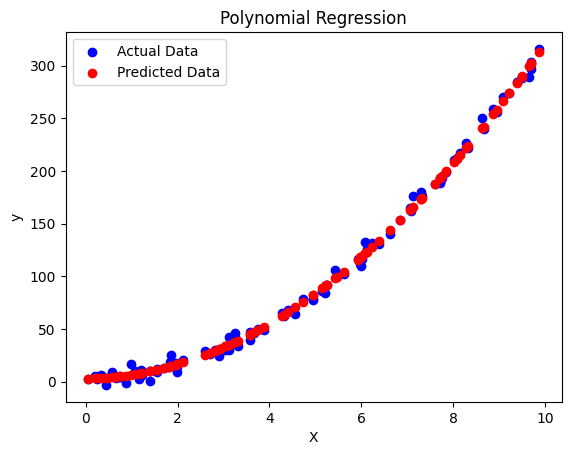

In [8]:
# Generate synthetic data
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 random points between 0 and 10
y = 3 * X**2 + 2 * X + np.random.randn(100, 1) * 5  # Quadratic relationship with noise

# Transform features to polynomial features
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Fit Polynomial Regression model
model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)


# Plotting the results
plt.scatter(X, y, color='blue', label='Actual Data')
plt.scatter(X, y_pred, color='red', label='Predicted Data')
plt.title('Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

# Evaluate the model
mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error: {mse:.2f}')

In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Ridge Regression for regularization
ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

# Lasso Regression for regularization
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

# Evaluate Ridge and Lasso models
ridge_mse = mean_squared_error(y_test, ridge_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
print(f'Ridge Mean Squared Error: {ridge_mse:.2f}')
print(f'Lasso Mean Squared Error: {lasso_mse:.2f}')

Ridge Mean Squared Error: 15.90
Lasso Mean Squared Error: 15.91


### Exercise 1: Implement Polynomial Regression and Visualize the Fit

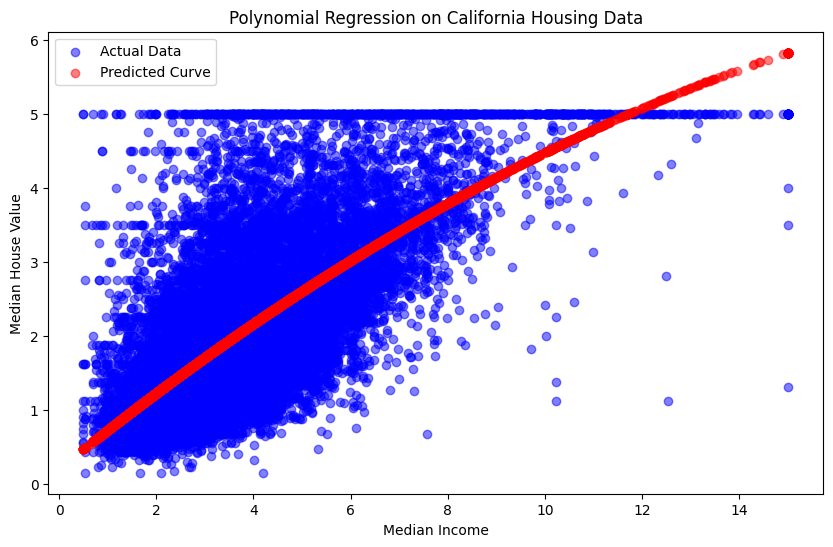

Mean Squared Error: 0.70


In [13]:
# Load California housing dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Select features (median income) and target (median house value)
X = df[['MedInc']]
y = df['MedHouseVal']

# Transform features to polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Fit Polynomial Regression model
model = LinearRegression()
model.fit(X_poly, y)

# Make predictions
y_pred = model.predict(X_poly)

# Plotting actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data', alpha=0.5)
plt.scatter(X, y_pred, color='red', label='Predicted Curve', alpha=0.5)
plt.title('Polynomial Regression on California Housing Data')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.show()

# Evaluate the model
mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error: {mse:.2f}')



### Exercise 2: Use Lasso and Ridge Regression

Ridge Mean Squared Error: 0.70
Lasso Mean Squared Error: 0.72


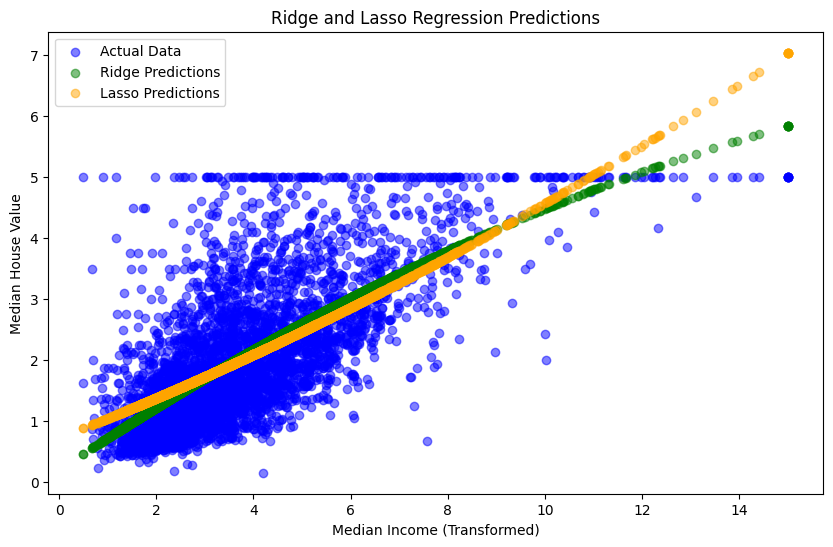

In [14]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Ridge Regression
ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)


# Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)


# Evaluate models
ridge_mse = mean_squared_error(y_test, ridge_pred)
print(f'Ridge Mean Squared Error: {ridge_mse:.2f}')
lasso_mse = mean_squared_error(y_test, lasso_pred)
print(f'Lasso Mean Squared Error: {lasso_mse:.2f}')

# Visualize Ridge and Lasso predictions
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', label='Actual Data', alpha=0.5)
plt.scatter(X_test[:, 0], ridge_pred, color='green', label='Ridge Predictions', alpha=0.5)
plt.scatter(X_test[:, 0], lasso_pred, color='orange', label='Lasso Predictions', alpha=0.5)
plt.title('Ridge and Lasso Regression Predictions')
plt.xlabel('Median Income (Transformed)')
plt.ylabel('Median House Value')
plt.legend()
plt.show()
